In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
%pip install xgboost
from xgboost import XGBRegressor
#Step 2. Create a normal regression dataset

#Start with a simple relationship.

#Suppose:

#$$ Y = 3 + 2X_1 + 1.5X_2 - X_3 + \epsilon $$

#Generate 1,000 observations.
np.random.seed(42)

n = 1000

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

error = np.random.normal(0, 1, n)

Y = 3 + 2*X1 + 1.5*X2 - X3 + error

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "Y": Y
})

df.head()
#Step 3. Split the data
X = df[["X1", "X2", "X3"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#80% training, 20% testing.
#Step 4. Create a function to compare models
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Huber": HuberRegressor(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)
results = evaluate_models(
    X_train, X_test, y_train, y_test
)

results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.876029
1,Ridge,1.037339,0.827542,0.875933
2,Huber,1.037429,0.828090,0.875911
3,Random Forest,1.228379,0.956959,0.826028
4,XGBoost,1.132448,0.897738,0.852140


In [3]:
#Generate multicollimear data
def generate_multicollinear_data(
    n=1000,
    seed=42
):

    np.random.seed(seed)

    X1 = np.random.normal(0, 1, n)

    X2 = (
        X1
        + np.random.normal(0, 0.1, n)
    )

    X3 = np.random.normal(0, 1, n)

    error = np.random.normal(0, 1, n)

    Y = (
        3
        + 2 * X1
        + 1.5 * X2
        - X3
        + error
    )

    return pd.DataFrame({
        "X1": X1,
        "X2": X2,
        "X3": X3,
        "Y": Y
    })



In [4]:
#Genrate
data = generate_multicollinear_data()

data[["X1", "X2", "X3"]].corr()

,X1,X2,X3
X1,1.000000,0.994818,0.022129
X2,0.994818,1.000000,0.020966
X3,0.022129,0.020966,1.000000


<ipython-input-5-d6c13344a786>:16: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig(
<ipython-input-5-d6c13344a786>:16: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig(


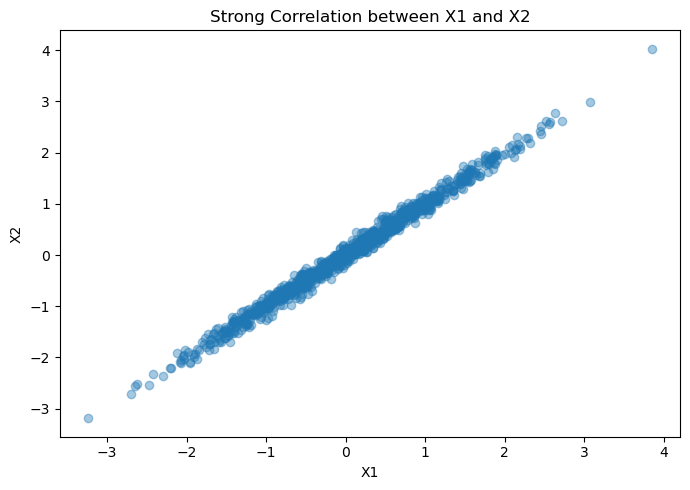

In [5]:
#Visualize correlation
plt.figure(figsize=(7, 5))

plt.scatter(
    data["X1"],
    data["X2"],
    alpha=0.4
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Strong Correlation between X1 and X2")

plt.tight_layout()

plt.savefig(
    "../results/figures/multicollinearity_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
#Evaluate models
X = data[["X1", "X2", "X3"]]
y = data["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

multi_results = evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
)

multi_results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.921284
1,Ridge,1.034399,0.824587,0.921669
2,Huber,1.037427,0.828088,0.921210
3,Random Forest,1.199706,0.981640,0.894633
4,XGBoost,1.138818,0.891024,0.905057


In [8]:
#save
multi_results.to_csv(
    "../results/tables/multicollinearity_results.csv",
    index=False
)